In [1]:
import os
Dataset_File = "Glass.csv"

if not os.path.isfile(Dataset_File):
  os.system("wget https://raw.githubusercontent.com/cnchi/datasets/master/" + Dataset_File)

## 使用PyTorch幫玻璃劃分等級

*   模型：OpenAI ChatGPT 4o-mini
*   以下內容都為提詞




請參考附件Glass.csv，其中最後一欄為應變數，其餘都是自變數。資料集欄位說明如下：

* 自變數 X
1. RI：折射率（Refractive Index）
2. Na：鈉含量
3. Mg：鎂含量
4. Al：鋁含量
5. Si：矽含量
6. K：鉀含量
7. Ca：鈣含量
8. Ba：鋇含量
9. Fe：鐵含量

* 應變數 Y
1. Type：等級，一共有 1～7 等。

請幫我用PyTorch寫出一個多選一分類器，根據自變數幫玻璃進行分級。其中資料須先經過適當的前處理，並且Y_test與Y_pred請幫我如圖所示「肩並肩」印出，最後請再使用.evaluate()函數來評估模型的正確性，並印出該模型效能有多好

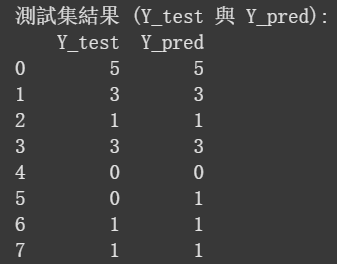

In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# 1. 資料讀取
data = pd.read_csv("Glass.csv")

# 2. 資料前處理
X = data.iloc[:, :-1].values  # 自變數 (RI, Na, Mg, Al, Si, K, Ca, Ba, Fe)
Y = data.iloc[:, -1].values   # 應變數 (Type)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, Y_train)
test_dataset = TensorDataset(X_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# 3. 建立模型
class GlassClassifier(nn.Module):
    def __init__(self):
        super(GlassClassifier, self).__init__()
        self.fc1 = nn.Linear(9, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 8)  # 類別數量 (1~7，共7種，但加1避免0-index問題)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return self.softmax(x)

model = GlassClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 4. 訓練模型
epochs = 100
for epoch in range(epochs):
    model.train()
    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch - 1)  # Label 調整為 0-index
        loss.backward()
        optimizer.step()

In [ ]:
# 5. 預測並顯示 Y_test 與 Y_pred
model.eval()
y_pred = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.cpu().numpy() + 1)  # 恢復為 1-index

Y_pred = pd.Series(y_pred)
Y_test_df = pd.Series(Y_test.numpy())
result = pd.concat([Y_test_df, Y_pred], axis=1)
result.columns = ['Y_test', 'Y_pred']
print("測試集結果 (Y_test 與 Y_pred):")
print(result)

In [ ]:
# 6. 評估模型
correct = (Y_pred.values == Y_test.numpy()).sum()
total = len(Y_test)
accuracy = correct / total
print(f'模型正確率: {accuracy * 100:.2f}%')